> **Chapter 15, Part 7** | Engineering lens. **Capstone.** Build a real asset graph for the repo's trading platform, partition it by trading day, run it, and backfill a week.

# Capstone: Orchestrate the Trading Platform's Data

The trading platform (Applied System A) moves market data into portfolio views and an "Ask Warren" analysis surface. Today that flow is implicit, spread across the Flask API and the Streamlit app. Here we make it an explicit asset graph:

```
market_data -> price_history -> positions -> daily_pnl -> warren_context
```

Each asset is partitioned by trading day. We generate synthetic OHLC bars (no network), materialize one day, then backfill a trading week. The compute functions are real pandas, so this is a working pipeline, just with a synthetic source standing in for yfinance.

In [1]:
# The tiny orchestrator we build across 15.1-15.3, collected into one cell.
from collections import deque
from dataclasses import dataclass
from typing import Callable, Optional


@dataclass
class Asset:
    name: str
    deps: list
    compute: Callable
    partitioned: bool = False


class AssetGraph:
    def __init__(self):
        self.assets = {}

    def add(self, asset):
        self.assets[asset.name] = asset
        return self

    def _downstream(self):
        down = {n: [] for n in self.assets}
        for n, a in self.assets.items():
            for d in a.deps:
                if d in down:
                    down[d].append(n)
        return down

    def topological_order(self):
        indeg = {n: 0 for n in self.assets}
        for n, a in self.assets.items():
            for d in a.deps:
                if d in indeg:
                    indeg[n] += 1
        down = self._downstream()
        q = deque(sorted(n for n, k in indeg.items() if k == 0))
        order = []
        while q:
            n = q.popleft()
            order.append(n)
            for m in sorted(down[n]):
                indeg[m] -= 1
                if indeg[m] == 0:
                    q.append(m)
        if len(order) != len(self.assets):
            stuck = sorted(n for n in self.assets if n not in order)
            raise ValueError("cycle detected among assets: " + ", ".join(stuck))
        return order

    def _needed(self, targets):
        need = set()
        stack = list(targets)
        while stack:
            n = stack.pop()
            if n in need or n not in self.assets:   # ignore refs outside the graph
                continue
            need.add(n)
            stack.extend(self.assets[n].deps)
        return need

    def materialize(self, targets=None, log=None, partition=None, verbose=True):
        order = self.topological_order()
        if targets is not None:
            need = self._needed(targets)
            order = [n for n in order if n in need]
        results = {}
        for n in order:
            tag = " [" + str(partition) + "]" if partition is not None else ""
            if log is not None and log.is_materialized(n, partition):
                results[n] = log.value(n, partition)
                if verbose:
                    print("  skip   " + n + tag + " (already materialized)")
                continue
            inputs = {d: results.get(d) for d in self.assets[n].deps}
            value = self.assets[n].compute(inputs)
            results[n] = value
            if log is not None:
                log.record(n, partition, value)
            if verbose:
                print("  build  " + n + tag)
        return results


class MaterializationLog:
    def __init__(self):
        self.store = {}

    def is_materialized(self, name, partition=None):
        return (name, partition) in self.store

    def record(self, name, partition=None, value=None):
        self.store[(name, partition)] = value

    def value(self, name, partition=None):
        return self.store[(name, partition)]


def backfill(graph, target, partitions, log, verbose=True):
    report = {"materialized": [], "skipped": []}
    order = [n for n in graph.topological_order() if n in graph._needed([target])]
    for p in partitions:
        for n in order:
            if log.is_materialized(n, p):
                report["skipped"].append((n, p))
                continue
            inputs = {d: (log.value(d, p) if log.is_materialized(d, p) else None)
                      for d in graph.assets[n].deps}
            log.record(n, p, graph.assets[n].compute(inputs))
            report["materialized"].append((n, p))
    return report


def blast_radius(graph, failed):
    down = graph._downstream()
    seen, stack = set(), list(down[failed])
    while stack:
        n = stack.pop()
        if n in seen:
            continue
        seen.add(n)
        stack.extend(down[n])
    return seen


@dataclass
class RetryPolicy:
    max_attempts: int = 1


def materialize_with_failures(graph, failing=None, retry=None, verbose=True):
    failing = failing or {}
    retry = retry or RetryPolicy()
    order = graph.topological_order()
    status, results, attempts_used = {}, {}, {}
    for n in order:
        if any(status.get(d) in ("failed", "skipped") for d in graph.assets[n].deps):
            status[n] = "skipped"
            if verbose:
                print("  skip    " + n + " (upstream failed)")
            continue
        attempts, ok = 0, False
        while attempts < retry.max_attempts:
            attempts += 1
            if attempts <= failing.get(n, 0):
                if verbose:
                    print("  retry   " + n + " attempt " + str(attempts) + " failed")
                continue
            ok = True
            break
        attempts_used[n] = attempts
        if ok:
            inputs = {d: results.get(d) for d in graph.assets[n].deps}
            results[n] = graph.assets[n].compute(inputs)
            status[n] = "materialized"
            if verbose:
                print("  build   " + n + " (attempt " + str(attempts) + ")")
        else:
            status[n] = "failed"
            if verbose:
                print("  FAIL    " + n + " (exhausted " + str(retry.max_attempts) + " attempts)")
    return status, results, attempts_used


print("orchestrator core ready:", len([Asset, AssetGraph, MaterializationLog,
      backfill, blast_radius, RetryPolicy, materialize_with_failures]), "building blocks")

orchestrator core ready: 7 building blocks


In [2]:
import numpy as np
import pandas as pd

TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN"]
rng = np.random.default_rng(15)


def gen_market_data(inputs, day=None):
    # synthetic OHLC bars for the day, one row per ticker
    base = rng.uniform(80, 400, size=len(TICKERS))
    spread = rng.uniform(1, 6, size=len(TICKERS))
    return pd.DataFrame({
        "ticker": TICKERS,
        "open": base,
        "high": base + spread,
        "low": base - spread,
        "close": base + rng.uniform(-2, 2, size=len(TICKERS)),
        "day": day,
    })


def price_history(inputs, day=None):
    md = inputs["market_data"]
    return md[["ticker", "close", "day"]].copy()


def positions(inputs, day=None):
    # a fixed book of shares per ticker
    shares = {"AAPL": 50, "MSFT": 30, "NVDA": 20, "AMZN": 10}
    ph = inputs["price_history"]
    out = ph.copy()
    out["shares"] = out["ticker"].map(shares)
    out["market_value"] = out["close"] * out["shares"]
    return out


def daily_pnl(inputs, day=None):
    pos = inputs["positions"]
    return pd.DataFrame({"day": [day], "portfolio_value": [pos["market_value"].sum()]})


def warren_context(inputs, day=None):
    pnl = inputs["daily_pnl"]
    val = pnl["portfolio_value"].iloc[0]
    return f"On {day} the portfolio was worth ${val:,.0f}."


print("compute functions ready for", len(TICKERS), "tickers")

compute functions ready for 4 tickers


The asset graph closes over the partition day so each compute knows which day it is building. We materialize a single trading day end to end and read off the Ask Warren context the graph produced.

In [3]:
def build_graph(day):
    g = AssetGraph()
    g.add(Asset("market_data", [], lambda i: gen_market_data(i, day), partitioned=True))
    g.add(Asset("price_history", ["market_data"], lambda i: price_history(i, day), partitioned=True))
    g.add(Asset("positions", ["price_history"], lambda i: positions(i, day), partitioned=True))
    g.add(Asset("daily_pnl", ["positions"], lambda i: daily_pnl(i, day), partitioned=True))
    g.add(Asset("warren_context", ["daily_pnl"], lambda i: warren_context(i, day), partitioned=True))
    return g


day = "2026-06-08"
g = build_graph(day)
print("run order:", " -> ".join(g.topological_order()))
print()
results = g.materialize(verbose=True)
print()
print("Ask Warren context:", results["warren_context"])

run order: market_data -> price_history -> positions -> daily_pnl -> warren_context

  build  market_data
  build  price_history
  build  positions
  build  daily_pnl
  build  warren_context

Ask Warren context: On 2026-06-08 the portfolio was worth $30,148.


## Backfill the trading week

Monday to Friday. Each day rebuilds the graph for that partition (the source closes over the day) and materializes it. We collect the daily portfolio value the pipeline computed and plot the week.

On 2026-06-08 the portfolio was worth $29,715.
On 2026-06-09 the portfolio was worth $32,603.
On 2026-06-10 the portfolio was worth $16,233.
On 2026-06-11 the portfolio was worth $32,782.
On 2026-06-12 the portfolio was worth $34,912.


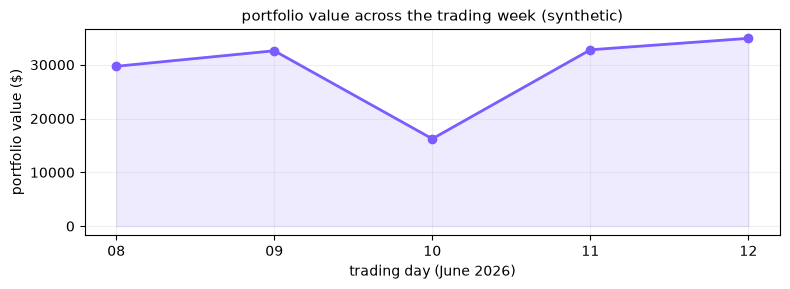

In [4]:
import matplotlib.pyplot as plt

trading_week = ["2026-06-08", "2026-06-09", "2026-06-10", "2026-06-11", "2026-06-12"]
values = []
for d in trading_week:
    res = build_graph(d).materialize(verbose=False)
    values.append(res["daily_pnl"]["portfolio_value"].iloc[0])
    print(res["warren_context"])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot([d[-2:] for d in trading_week], values, marker="o", color="#7c5cff", linewidth=2)
ax.fill_between([d[-2:] for d in trading_week], values, alpha=0.12, color="#7c5cff")
ax.set_title("portfolio value across the trading week (synthetic)", fontsize=11)
ax.set_xlabel("trading day (June 2026)")
ax.set_ylabel("portfolio value ($)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

That is the trading platform as an orchestrated asset graph: partitioned by day, materialized in dependency order, backfillable across a week, and ending in the exact context string the Ask Warren surface consumes. Swap the synthetic source for yfinance and the same graph runs against live data. Last notebook: the failure modes, because none of this is free.